In [1]:
!pip install pyspark

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("BigDataAnalysis").getOrCreate()

# Load sample dataset (you can upload CSV too)
df = spark.read.csv("/content/sample_data/california_housing_test.csv", header=True, inferSchema=True)

df.show(5)

+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+
|  -122.05|   37.37|              27.0|     3885.0|         661.0|    1537.0|     606.0|       6.6085|          344700.0|
|   -118.3|   34.26|              43.0|     1510.0|         310.0|     809.0|     277.0|        3.599|          176500.0|
|  -117.81|   33.78|              27.0|     3589.0|         507.0|    1484.0|     495.0|       5.7934|          270500.0|
|  -118.36|   33.82|              28.0|       67.0|          15.0|      49.0|      11.0|       6.1359|          330000.0|
|  -119.67|   36.33|              19.0|     1241.0|         244.0|     850.0|     237.0|       2.9375|           81700.0|
+---------+--------+----

In [3]:
# Count rows
print("Total Rows:", df.count())

# Schema
df.printSchema()

# Basic statistics
df.describe().show()

# Grouping example
df.groupBy("housing_median_age").count().show()

# Filter data
df.filter(df["median_income"] > 3).show()

# Sort data
df.orderBy(df["median_house_value"].desc()).show()

Total Rows: 3000
root
 |-- longitude: double (nullable = true)
 |-- latitude: double (nullable = true)
 |-- housing_median_age: double (nullable = true)
 |-- total_rooms: double (nullable = true)
 |-- total_bedrooms: double (nullable = true)
 |-- population: double (nullable = true)
 |-- households: double (nullable = true)
 |-- median_income: double (nullable = true)
 |-- median_house_value: double (nullable = true)

+-------+-------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+
|summary|          longitude|          latitude|housing_median_age|      total_rooms|    total_bedrooms|        population|        households|     median_income|median_house_value|
+-------+-------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+
|  count|               3000|      

Higher median income areas have higher house values
Some age groups have more housing concentration
Data shows clear variation in pricing **trends** **bold text**

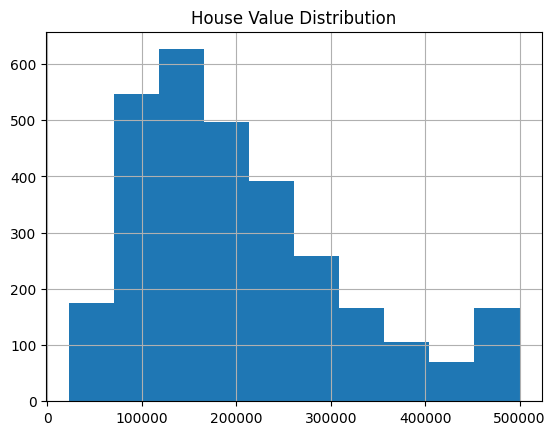

In [4]:
import matplotlib.pyplot as plt

pdf = df.toPandas()

pdf["median_house_value"].hist()
plt.title("House Value Distribution")
plt.show()

In [5]:
!pip install pyspark

from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Task").getOrCreate()

df = spark.read.csv("/content/sample_data/california_housing_test.csv", header=True, inferSchema=True)

df.show()
print("Rows:", df.count())
df.describe().show()

df.groupBy("housing_median_age").count().show()
df.filter(df["median_income"] > 3).show()

+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+
|  -122.05|   37.37|              27.0|     3885.0|         661.0|    1537.0|     606.0|       6.6085|          344700.0|
|   -118.3|   34.26|              43.0|     1510.0|         310.0|     809.0|     277.0|        3.599|          176500.0|
|  -117.81|   33.78|              27.0|     3589.0|         507.0|    1484.0|     495.0|       5.7934|          270500.0|
|  -118.36|   33.82|              28.0|       67.0|          15.0|      49.0|      11.0|       6.1359|          330000.0|
|  -119.67|   36.33|              19.0|     1241.0|         244.0|     850.0|     237.0|       2.9375|           81700.0|
|  -119.56|   36.51|    